In [3]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv("online_education_dataset.csv")
print(df)

       id_student gender                region      highest_education  \
0           11391      M   East Anglian Region       HE Qualification   
1           28400      F              Scotland       HE Qualification   
2           30268      F  North Western Region  A Level or Equivalent   
3           31604      F     South East Region  A Level or Equivalent   
4           32885      F  West Midlands Region     Lower Than A Level   
...           ...    ...                   ...                    ...   
32588     2640965      F                 Wales     Lower Than A Level   
32589     2645731      F   East Anglian Region     Lower Than A Level   
32590     2648187      F          South Region  A Level or Equivalent   
32591     2679821      F     South East Region     Lower Than A Level   
32592     2684003      F      Yorkshire Region       HE Qualification   

       studied_credits imd_band  total_clicks  avg_score engagement_level  \
0                  240  90-100%         934.0 

In [21]:
df["final_result"].value_counts()

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


In [8]:
df.groupby("final_result").count()

,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag
final_result,,,,,,,,,,,,,
Distinction,3024,3024,3024,3024,3024,2825,3024,3024,3024,3024,3024,3024,3024
Fail,7052,7052,7052,7052,7052,6907,6719,5852,6719,5838,6719,7052,7052
Pass,12361,12361,12361,12361,12361,11830,12358,12359,12358,12359,12358,12361,12361
Withdrawn,10156,10156,10156,10156,10156,9920,7640,5492,7640,5474,7640,10156,10156


In [9]:
df.groupby("engagement_level")['pass_flag'].mean()

,pass_flag
engagement_level,
High,0.781354
Low,0.199194
Medium,0.571530


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

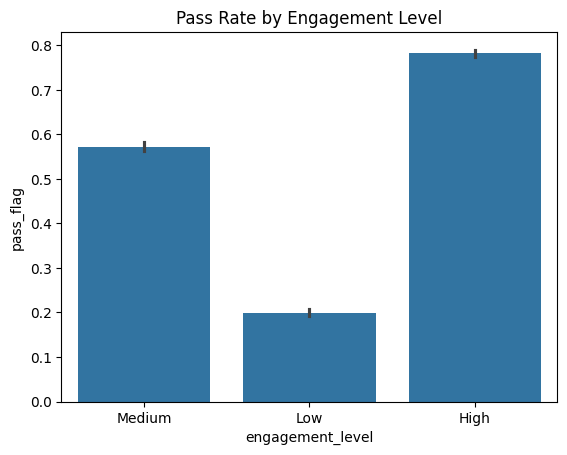

In [11]:
sns.barplot(x="engagement_level", y="pass_flag", data=df)
plt.title("Pass Rate by Engagement Level")
sns.set_style("whitegrid")
plt.show()

In [25]:
df["total_clicks"] = df["total_clicks"].fillna(0)
df["pass_flag"]=df["pass_flag"].fillna(0)

In [26]:
df[["total_clicks","pass_flag"]].isnull().sum()

,0
total_clicks,0
pass_flag,0


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [29]:
df_clean = df.dropna(subset=["total_clicks"])
X = df_clean[["total_clicks"]]
y = df_clean["pass_flag"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LogisticRegression()
model.fit(X_scaled, y)

LogisticRegression()

In [17]:
print("Model coefficient:",model.coef_[0][0])

Model coefficient: 1.4141169883617175


<Axes: xlabel='engagement_level', ylabel='pass_flag'>

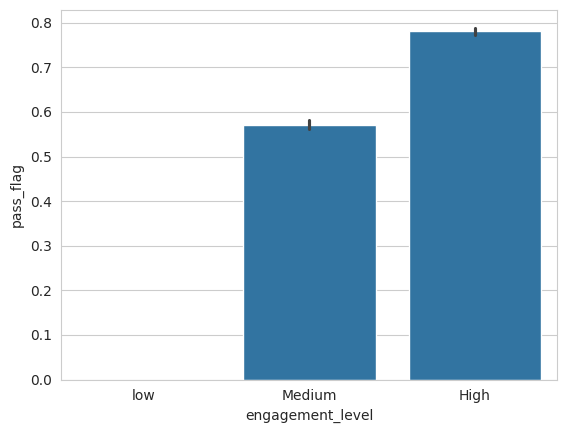

In [19]:
sns.barplot
 (
    x = "engagement_level",
    y = "pass_flag",
    data = df,
    order =["low","Medium","High"]
)

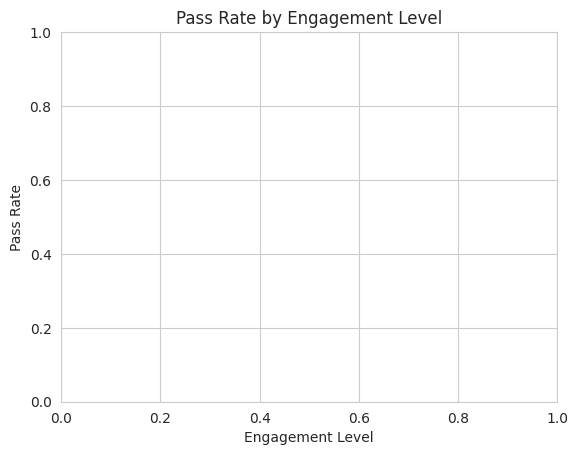

In [32]:
plt.title("Pass Rate by Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Pass Rate")
plt.savefig("pass_rate_by_engagement.png", dpi=300, bbox_inches="tight")
plt.show()